<a href="https://colab.research.google.com/github/gilIolgenblum/CrowdingModeWorkshop/blob/main/tutorials/solutions/E0_determination_of_parameters_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 4: Determination of Flory–Huggins Parameters

Before we can simulate or fit protein-stability data, we need the three Flory–Huggins (FH) cosolute parameters:

| Parameter | Symbol | Physical meaning |
|-----------|--------|------------------|
| Excluded volume | $\nu$ | Size of a cosolute molecule |
| Non-ideal interaction parameter | $\chi$ | Net gain or loss of free-energy from cosolute–solvent interaction at 25 °C |
| Entropic non-ideal interaction | $\chi_{TS}$ | Entropic contribution to $\chi$ |

In this exercise you will **derive these three parameters from scratch** using only:
1. **Density vs. molality** tables → gives $\nu$.
2. **Water activity vs. $\phi_C$** at 25 °C → gives $\chi$.
3. **Temperature dependence of water activity** → separates $\chi$ into $\chi_H$ and $\chi_{TS}$.

We will work through **Glycerol** step-by-step, and you will then repeat the analysis for **Sucrose**.

> **Note:** All parameters derived here are published values taken from *Olgenblum, G. I.; Carmon, N.; Harries, D. JACS (2023)* .


In [1]:
import os
import sys

# Check if we are running in Google Colab
if 'google.colab' in str(get_ipython()):
    !git clone https://github.com/gilIolgenblum/CrowdingModeWorkshop.git
    os.chdir('/content/CrowdingModeWorkshop')
    !pip install -e .
    sys.path.append('/content/CrowdingModeWorkshop/src')


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import crowding as cr


---
## Part 1 — Excluded-Volume Parameter $\nu$ from Density Data

### Background

In the Flory–Huggins lattice description, each lattice site corresponds to the volume occupied by one water molecule. The **excluded volume parameter** $\nu$ quantifies the effective size of a cosolute in units of water-sized lattice sites.

$$\nu = \frac{\bar{V}_C}{\bar{V}_W}$$

where $\bar{V}_C$ and $\bar{V}_W$ are the **partial molar volumes** (ml/mol) of the cosolute and water, respectively.

### Density data

The table below contains solution densities (g/ml) measured at 25 °C for **Glycerol** and **Sucrose** using an oscillating U-tube densitometer.

In [3]:
# ── Density data at 25 °C ─────────────────────────────────────────────
# Each entry: (molality [mol/kg water], density [g/ml])

density_data = {
    "Glycerol": {
        "M": 92.09,
        "data": pd.DataFrame({
            "molal":   [0, 0.600, 1.221, 1.801, 2.420, 2.953, 3.544, 4.219, 4.747],
            "density": [0.99703, 1.00940, 1.02126, 1.03097, 1.04044, 1.04819, 1.05680, 1.06457, 1.07134]
        })
    },
    
    "Sucrose": {
        "M": 342.30,
        "data": pd.DataFrame({
            "molal":   [0, 0.600, 1.196, 1.797, 2.393, 2.999, 3.606, 4.198, 4.797],
            "density": [0.99703, 1.06605, 1.12060, 1.16469, 1.20060, 1.23092, 1.25639, 1.27806, 1.29872]
        })
    },
}

print("Density data loaded for:", list(density_data.keys()))


Density data loaded for: ['Glycerol', 'Sucrose']


---
### Task C1 — Plotting
Plot density vs molal for the two cosolutes

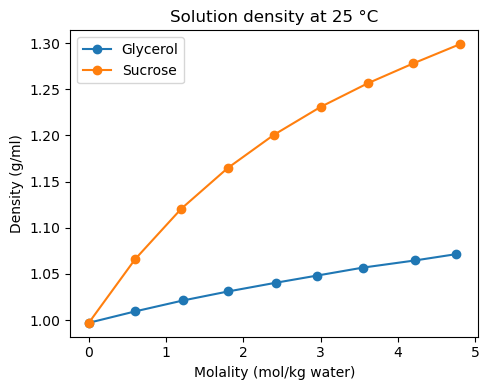

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))

for name, entry in density_data.items():
    df = entry['data']
    ax.plot(df['molal'], df['density'], 'o-', label=name)

ax.set_xlabel('Molality (mol/kg water)')
ax.set_ylabel('Density (g/ml)')
ax.set_title('Solution density at 25 °C')
ax.legend()
plt.tight_layout()
plt.show()


---
### Task C2 — mole fraction, molar volume, and $\nu$ (Glycerol, Worked Example)

The solution molar volume ($\bar{V}$) can be given as a linear combination of the partial molar volumes of the cosolute ($\bar{V_c}$) and solvent ($\bar{V_s}$):

$$
\bar{V} = \bar{V}_s + x (\bar{V}_c-\bar{V}_s) 
$$

To determine $\bar{V}_s$ and $\bar{V}_c$ we need to extrapolate to mole fraction ($x$) as follows:
$$
\bar{V}_s = \lim{\bar{V}}_{x\to 0}
$$
$$
\bar{V}_c = \lim{\bar{V}}_{x\to 1}
$$


The solution mole fraction can be calculated using:
$$
x = \frac{\mathrm{molal}}{\mathrm{molal}+1000/M_\mathrm{solvent}}
$$

The molar volume is given by:
$$
\bar{V} = \frac{x M_\mathrm{cosolute} + (1-x) M_\mathrm{solvent}}{\rho}
$$



**Steps:**
1. Compute $x$ from molal for glycerol solutions using the formula above.
2. Determine the values of $\bar{V}$.
3. Fit to a linear model and determine the values of $\bar{V}_c$, $\bar{V}_s$, and $\nu$ with their uncertienties. 
4. Plot $\bar{V}$ vs $x$ with the linear fit.

*Hint: use `scipy.optimize.curve_fit`.*


In [5]:
# helper functions:
def cal_x(molal, MW):
    return molal / (molal + 1000.0 / MW)

def cal_V(x, density, MW, MC):
    return (x * MC + (1 - x) * MW) / density

def V_mix_model(x, V_s, V_c):
    return V_s + x * (V_c - V_s)


In [6]:
M_W = 18.015   # g/mol, molar mass of water

# ── Glycerol: initialize data
name    = 'Glycerol'
M_C     = density_data[name]['M']          # g/mol
df_gly  = density_data[name]['data'].copy()

# Step 1 — mole fraction x
df_gly['x'] = cal_x(df_gly['molal'], M_W)

# Step 2 — mixture molar volume  V̄ = (x·M_C + (1-x)·M_W) / ρ  [ml/mol]
df_gly['V_mix'] = cal_V(df_gly['x'], df_gly['density'], M_W, M_C)

df_gly

,molal,density,x,V_mix
0,0.000,0.99703,0.000000,18.068664
1,0.600,1.00940,0.010693,18.631974
2,1.221,1.02126,0.021523,19.201093
3,1.801,1.03097,0.031425,19.731746
4,2.420,1.04044,0.041775,20.289001
5,2.953,1.04819,0.050511,20.756367
6,3.544,1.05680,0.060014,21.253318
7,4.219,1.06457,0.070637,21.837363
8,4.747,1.07134,0.078780,22.262437


In [7]:
# Step 3 — linear fit  V̄(x) = V_s + x·(V_c - V_s)
from scipy.optimize import curve_fit

x_data = df_gly['x'].values
V_data = df_gly['V_mix'].values

popt, pcov = curve_fit(V_mix_model, x_data, V_data, p0=[18.0, 75.0])
V_s_fit, V_c_fit = popt
V_s_err, V_c_err = np.sqrt(np.diag(pcov))

nu_gly = V_c_fit / V_s_fit
nu_err = np.sqrt((V_s_fit**(-1)*V_c_err)**2 + \
        (V_c_fit / V_s_fit**2 * V_s_err)**2)
print(f'\nGlycerol fit results:')
print(f'  V̄_s  = {V_s_fit:.3f} ± {V_s_err:.3f} ml/mol')
print(f'  V̄_c  = {V_c_fit:.3f} ± {V_c_err:.3f} ml/mol')
print(f'  ν    = V̄_c / V̄_s = {nu_gly:.3f} ± {nu_err:.3f}')


Glycerol fit results:
  V̄_s  = 18.061 ± 0.004 ml/mol
  V̄_c  = 71.391 ± 0.083 ml/mol
  ν    = V̄_c / V̄_s = 3.953 ± 0.005


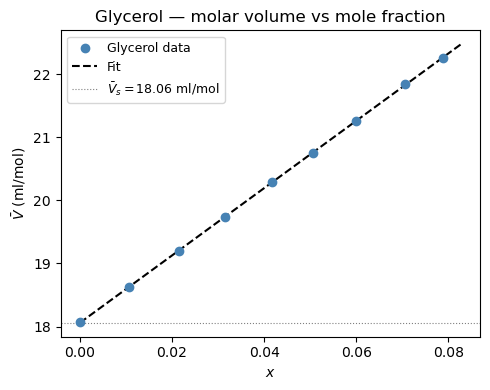

In [8]:
# Step 4 — plot
x_fine = np.linspace(0, x_data.max() * 1.05, 200)
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(x_data, V_data, color='steelblue', zorder=5, label='Glycerol data')
ax.plot(x_fine, V_mix_model(x_fine, V_s_fit, V_c_fit), 'k--',
        label=fr'Fit')
ax.axhline(V_s_fit, color='grey', lw=0.8, ls=':', label=fr'$\bar{{V}}_s = {V_s_fit:.2f}$ ml/mol')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\bar{V}$ (ml/mol)')
ax.set_title('Glycerol — molar volume vs mole fraction')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


---
### Task C3 — Determine $\nu$ for Sucrose

Repeat the procedure of Task C2 for **Sucrose** ($M_C = 342.30$ g/mol) and determine it's value of $\nu$.


**Question (answer below):** Why is $\nu_{\rm Sucrose} \gt \nu_{\rm Glycerol}$?


Sucrose fit results:
  V̄_s  = 18.036 ± 0.014 ml/mol
  V̄_c  = 215.356 ± 0.278 ml/mol
  ν    = V̄_c / V̄_s = 11.940 ± 0.018  (literature: 11.9)


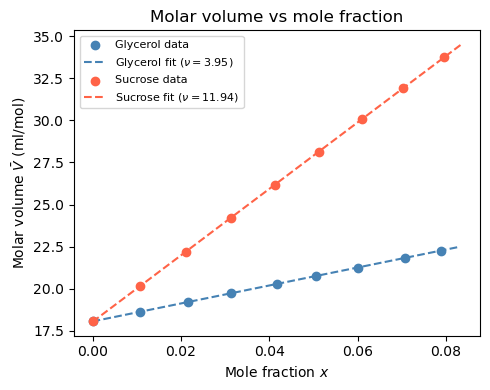

In [9]:
name    = 'Sucrose'
M_C     = density_data[name]['M']          # g/mol
df_suc  = density_data[name]['data'].copy()

df_suc['x']     = cal_x(df_suc['molal'], M_W)
df_suc['V_mix'] = cal_V(df_suc['x'], df_suc['density'], M_W, M_C)

x_data_s = df_suc['x'].values
V_data_s = df_suc['V_mix'].values

popt_s, pcov_s = curve_fit(V_mix_model, x_data_s, V_data_s, p0=[18.0, 215.0])
V_s_suc, V_c_suc = popt_s
V_s_err_s, V_c_err_s = np.sqrt(np.diag(pcov_s))

nu_suc     = V_c_suc / V_s_suc
nu_err_s   = np.sqrt((V_s_suc**(-1)*V_c_err_s)**2 + (V_c_suc/V_s_suc**2*V_s_err_s)**2)

print(f'Sucrose fit results:')
print(f'  V̄_s  = {V_s_suc:.3f} ± {V_s_err_s:.3f} ml/mol')
print(f'  V̄_c  = {V_c_suc:.3f} ± {V_c_err_s:.3f} ml/mol')
print(f'  ν    = V̄_c / V̄_s = {nu_suc:.3f} ± {nu_err_s:.3f}  (literature: 11.9)')

# Plot both cosolutes together
x_fine_g = np.linspace(0, df_gly['x'].max() * 1.05, 200)
x_fine_s = np.linspace(0, x_data_s.max() * 1.05, 200)
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(df_gly['x'], df_gly['V_mix'], color='steelblue', zorder=5, label='Glycerol data')
ax.plot(x_fine_g, V_mix_model(x_fine_g, V_s_fit, V_c_fit), color='steelblue', ls='--',
        label=fr'Glycerol fit ($\nu = {nu_gly:.2f}$)')
ax.scatter(x_data_s, V_data_s, color='tomato', zorder=5, label='Sucrose data')
ax.plot(x_fine_s, V_mix_model(x_fine_s, V_s_suc, V_c_suc), color='tomato', ls='--',
        label=fr'Sucrose fit ($\nu = {nu_suc:.2f}$)')
ax.set_xlabel('Mole fraction $x$')
ax.set_ylabel(r'Molar volume $\bar{V}$ (ml/mol)')
ax.set_title('Molar volume vs mole fraction')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


*✏️ Answer:* Sucrose is a much larger molecules than glycerol, and $\nu$ simply represents the relavent molecular volume.


---
## Part 2 — Interaction Parameter $\chi$ from Water Activity

### Background

In Flory–Huggins theory the osmotic pressure is given by:

$$\frac{\Pi\bar{V}_S}{k_BT} = -\ln(1 - \phi_C) + \left(1 - \frac{1}{\nu}\right)\phi_C + \chi\,\phi_C^2$$
where $\Pi=-\frac{RT}{\bar{V}_S}\ln a_S$

$\chi$ is determined from fits of $\frac{\Pi\bar{V}_S}{k_BT}$ vs $\phi_C$ at a fixed temperature of 25 °C (using the $\nu$ determined in Part 1).

### Water activity data

The tables below list $a_S$ at 15 °C, 25 °C, and 45 °C for **Glycerol** and **Sucrose** solutions, measured using a water activity meter.  
The 25 °C column gives $\chi$; the temperature dependence gives $\chi_{TS}$ (Part 3).


In [10]:
# ── Water activity data ────────────────────────────────────────────────
# Columns: phiC, a_W at 15°C, 25°C, 45°C

as_data = {
    "Glycerol": pd.DataFrame({
        "molal":  [1.22127, 1.80121, 2.41994, 2.95261, 3.54414, 4.21888, 4.74722],
        "phiC":   [0.07971, 0.11325, 0.14639, 0.17300, 0.20077, 0.22998, 0.25161],
        "aW_15":  [0.9778,  0.9678,  0.9566,  0.9470,  0.9363,  0.9256,  0.9151],
        "aW_25":  [0.9777,  0.9673,  0.9570,  0.9483,  0.9368,  0.9258,  0.9158],
        "aW_45":  [0.9785,  0.9679,  0.9572,  0.9488,  0.9390,  0.9264,  0.9184],
    }),
    "Sucrose": pd.DataFrame({
        "molal":  [0.6001, 1.19623, 1.79731, 2.39314, 2.99876, 3.60608, 4.19794, 4.79726],
        "phiC":   [0.11332, 0.20308, 0.27673, 0.33724, 0.38894, 0.43297, 0.47010, 0.50351],
        "aW_15":  [0.9885, 0.9743, 0.9599, 0.9451, 0.9292, 0.9126, 0.8968, 0.8778],
        "aW_20":  [0.9887, 0.9762, 0.9626, 0.9483, 0.9323, 0.9156, 0.8996, 0.8810],
        "aW_25":  [0.9893, 0.9778, 0.9648, 0.9498, 0.9336, 0.9173, 0.9005, 0.8833],
        "aW_45":  [0.98893, 0.9785, 0.96455, 0.95073, 0.93423, 0.91957, 0.90352, 0.8866],
    }),
}

print("Water activity data loaded for:", list(as_data.keys()))


Water activity data loaded for: ['Glycerol', 'Sucrose']


---
### Task C4 — Fit $\chi$ at 25 °C (Glycerol, Worked Example)

Using the $\nu$ value from Task C2 and the Glycerol water-activity data at 25 °C:

**Steps:**
1. Define a model function `as_model(phiC, chi)` that returns $\ln(a_S)$ from the FH expression.
2. Fit $\chi$ to the 25 °C $a_S$ data using `curve_fit`.
3. Plot the measured $a_S$ and the fitted FH curve vs $\phi_C$.

*Hint: fit $\ln(a_S)$ rather than $a_S$.*


In [11]:
# helper function
def Pi_model(phiC, chi):
    """Return ln(aS) predicted by FH, with nu fixed to the glycerol value."""
    return -(np.log(1 - phiC) + (1 - 1/nu_gly) * phiC + chi * phiC**2)


Glycerol  chi (25 °C) = 0.2269 ± 0.0054


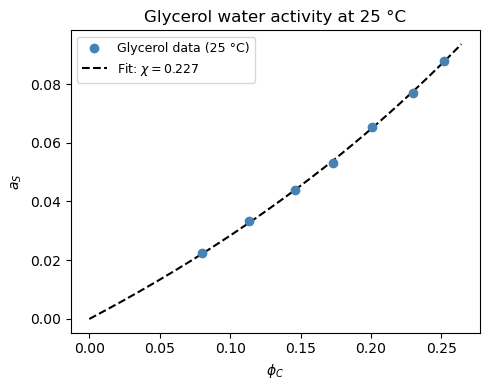

In [12]:
df_gly_aw = as_data['Glycerol']
phiC_gly = df_gly_aw['phiC'].values
ln_aS_gly25 = np.log(df_gly_aw['aW_25'].values)
scaled_Pi_gly25 = -ln_aS_gly25

popt_chi_g, pcov_chi_g = curve_fit(Pi_model, phiC_gly, scaled_Pi_gly25, p0=[0.3])
chi_gly = popt_chi_g[0]
chi_err_g = np.sqrt(pcov_chi_g[0, 0])
print(f'Glycerol  chi (25 °C) = {chi_gly:.4f} ± {chi_err_g:.4f}')

# Plot
phi_fine = np.linspace(0, phiC_gly.max() * 1.05, 200)
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(phiC_gly, scaled_Pi_gly25, color='steelblue', zorder=5, label='Glycerol data (25 °C)')
ax.plot(phi_fine, Pi_model(phi_fine, chi_gly), 'k--',
        label=fr'Fit: $\chi = {chi_gly:.3f}$')
ax.set_xlabel(r'$\phi_C$')
ax.set_ylabel(r'$a_S$')
ax.set_title('Glycerol water activity at 25 °C')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


---
### Task C5 — Fit $\chi$ at 25 °C (Sucrose)

Repeat Task C4 for **Sucrose** using the $\nu$ from Task C3.

**Question (answer below):** Glycerol has a smaller $\chi$ than sucrose. What does that tell you about how each cosolute interacts with water?


In [13]:
# helper function
def Pi_model_suc(phiC, chi):
    """Return ln(aS) predicted by FH, with nu fixed to the glycerol value."""
    return -(np.log(1 - phiC) + (1 - 1/nu_suc) * phiC + chi * phiC**2)


Sucrose   chi (25 °C) = 0.4503 ± 0.0008


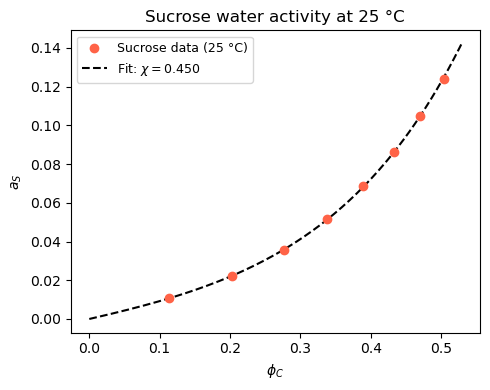

In [14]:
df_suc_aw = as_data['Sucrose']
phiC_suc = df_suc_aw['phiC'].values
ln_aS_suc25 = np.log(df_suc_aw['aW_25'].values)
scaled_Pi_suc25 = -ln_aS_suc25

popt_chi_s, pcov_chi_s = curve_fit(Pi_model_suc, phiC_suc, scaled_Pi_suc25, p0=[0.4])
chi_suc = popt_chi_s[0]
chi_err_s = np.sqrt(pcov_chi_s[0, 0])
print(f'Sucrose   chi (25 °C) = {chi_suc:.4f} ± {chi_err_s:.4f}')

phi_fine_s = np.linspace(0, phiC_suc.max() * 1.05, 200)
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(phiC_suc, scaled_Pi_suc25, color='tomato', zorder=5, label='Sucrose data (25 °C)')
ax.plot(phi_fine_s, Pi_model_suc(phi_fine_s, chi_suc), 'k--',
        label=fr'Fit: $\chi = {chi_suc:.3f}$')
ax.set_xlabel(r'$\phi_C$')
ax.set_ylabel(r'$a_S$')
ax.set_title('Sucrose water activity at 25 °C')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


*✏️ Answer:* A larger $\chi$ means stronger non-ideal (unfavourable) cosolute–water interactions. Sucrose ($\chi = 0.45$) interacts less favourably with water than glycerol ($\chi = 0.23$), meaning there are more cosolute-solvent repulsions.

---
## Part 3 — Entropic Interaction Parameter $\chi_{TS}$ from Temperature Dependence

### Background

The FH interaction parameter $\chi$ contains both enthalpic and entropic contributions:

$$\chi(T) = \chi_H - \chi_{TS}$$

where $\chi_H$ is the **enthalpic** contribution  and $\chi_{TS}$ is the **entropic** contribution.  

$\chi_H$ is determined from the temperature dependence of $\chi$ via the van 't Hoff relation:
$$
\frac{\partial \chi}{\partial T^{-1}}=T\;\chi_H
$$

In practice, usually $\chi$ vs $T^{-1}$ can be fitted by either a linear function, or a simple  Pad´e approximant:
$$
\chi=\frac{b_0+b_1 T^{-1}}{1+b_2 T^{-1}}
$$
for which the derivetive is:
$$
\frac{\partial\chi}{\partial T^{-1}}
=
\frac{b_1-b_0b_2}
{\left(1+b_2T^{-1}\right)^2}
$$



---
### Task C6 — Decompose $\chi$ into $\chi_H$ and $\chi_{TS}$ (Glycerol, Worked Example)

The Glycerol water-activity data is available at 15 °C, 25 °C, and 45 °C.

**Steps:**
1. For each temperature, fit $\chi(T)$ from the water-activity data to the FH equation (as in Task C4), using the $\nu$ already determined.
2. Plot $\chi$ vs $1/T$.
3. Fit a straight line: $\chi = \chi_H/T - \chi_{TS}$ and determine the values of $\chi_{H}$ and $\chi_{TS}$.

In [15]:
# where B = chiH (package intercept), A/T_ref = chiTS
def linear_chi(inv_T, A, B):
    return A * inv_T + B


  Glycerol 15 °C:  chi = 0.2145
  Glycerol 25 °C:  chi = 0.2269
  Glycerol 45 °C:  chi = 0.2611

Glycerol linear fit  chi(T) = A/T + B:
  A    = -144.86 ± 14.29 K
  B    = 0.7155 ± 0.0475 
  chiTS = A/T_ref = -0.4859 ± 0.0479 


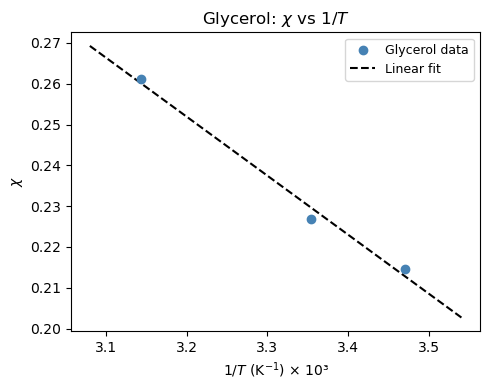

In [16]:
# Temperatures in Kelvin
temps_gly = {'15': 288.15, '25': 298.15, '45': 318.15}
T_ref = 298.15   # reference temperature for chiTS definition

# Step 1 — fit chi at each temperature
chi_gly_T = {}
for tlabel, T in temps_gly.items():
    col = f'aW_{tlabel}'
    ln_aS = np.log(as_data['Glycerol'][col].values)
    popt, _ = curve_fit(Pi_model, phiC_gly, -ln_aS, p0=[0.3])
    chi_gly_T[T] = popt[0]
    print(f'  Glycerol {tlabel} °C:  chi = {popt[0]:.4f}')

Ts_g   = np.array(list(chi_gly_T.keys()))
chis_g = np.array(list(chi_gly_T.values()))

# Step 2 — linear fit  chi(T) = A/T + B
popt_lin, pcov_lin = curve_fit(linear_chi, 1/Ts_g, chis_g)
A_gly, B_gly = popt_lin
A_err, B_err = np.sqrt(np.diag(pcov_lin))

chiTS_gly = A_gly / T_ref
chiH_gly  = B_gly          # chi(T→∞) = chiH in the package convention
chiTS_err = abs(A_err / T_ref)

print(f'\nGlycerol linear fit  chi(T) = A/T + B:')
print(f'  A    = {A_gly:.2f} ± {A_err:.2f} K')
print(f'  B    = {B_gly:.4f} ± {B_err:.4f} ')
print(f'  chiTS = A/T_ref = {chiTS_gly:.4f} ± {chiTS_err:.4f} ')

# Step 3 — plot chi vs 1/T
inv_T_fine = np.linspace(1/Ts_g.max()*0.98, 1/Ts_g.min()*1.02, 200)
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(1/Ts_g * 1e3, chis_g, color='steelblue', zorder=5, label='Glycerol data')
ax.plot(inv_T_fine * 1e3, linear_chi(inv_T_fine, *popt_lin), 'k--', label='Linear fit')
ax.set_xlabel(r'$1/T$ (K$^{-1}$) × 10³')
ax.set_ylabel(r'$\chi$')
ax.set_title(r'Glycerol: $\chi$ vs $1/T$')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


---
### Task C7 — Decompose $\chi$ into $\chi_H$ and $\chi_{TS}$ (Sucrose)

Repeat Task C6 for **Sucrose**. 

Detrmine the values of $\chi_H$ and $\chi_{TS}$ using a Pad´e approximant.

In [17]:
# Step 2b — Padé approximant  chi = (b0 + b1/T) / (1 + b2/T)
def pade_chi(inv_T, b0, b1, b2):
    return (b0 + b1 * inv_T) / (1 + b2 * inv_T)

def chi_H_error(T, popt, pcov):
    b0, b1, b2 = popt

    x = 1.0 / T
    N = b1 - b0 * b2
    D = 1.0 + b2 * x


    # Gradient of chi_H with respect to fitted parameters
    grad = np.array([
        -x * b2 / D**2,
         x / D**2,
        -x * b0 / D**2 - 2 * x**2 * N / D**3
    ])

    # Full covariance propagation
    chi_H_err = np.sqrt(grad @ pcov @ grad)

    return chi_H_err

In [18]:
# Temperatures for Sucrose (K)
temps_suc = {'15': 288.15, '20': 293.15, '25': 298.15, '45': 318.15}

# Step 1 — fit chi at each temperature
chi_suc_T = {}
for tlabel, T in temps_suc.items():
    col = f'aW_{tlabel}'
    ln_aS = np.log(as_data['Sucrose'][col].values)
    popt, _ = curve_fit(Pi_model_suc, phiC_suc, -ln_aS, p0=[0.4])
    chi_suc_T[T] = popt[0]
    print(f'  Sucrose {tlabel} °C:  chi = {popt[0]:.4f}')

T_s   = np.array(list(chi_suc_T.keys()))
chi_s = np.array(list(chi_suc_T.values()))

# Step 2a — Pade
popt_lin_s, pcov_lin_s = curve_fit(pade_chi, 1/T_s, chi_s)
b0, b1, b2 = popt_lin_s
b0_err, b1_err, b2_err = np.sqrt(np.diag(pcov_lin_s))
chiH_suc = (b1-b0*b2)/(1+b2*T_ref**(-1))**2 / T_ref
chiTS_suc = -chi_suc + chiH_suc
chiH_err_s = chi_H_error(T_ref,popt_lin_s, pcov_lin_s)
chiTS_err_s = np.sqrt(chiH_err_s**2+chi_err_s**2)  
print(f'\nSucrose Pde fit  chi(T) = (b1+b1T^-1)/(1+b2T^-1):')
print(f'  chiH = {chiH_suc:.4f} ± {chiH_err_s:.4f} ')
print(f'  chiTS = {chiTS_suc:.4f} ± {chiTS_err_s:.4f}')


  Sucrose 15 °C:  chi = 0.4228
  Sucrose 20 °C:  chi = 0.4406
  Sucrose 25 °C:  chi = 0.4503
  Sucrose 45 °C:  chi = 0.4626

Sucrose Pde fit  chi(T) = (b1+b1T^-1)/(1+b2T^-1):
  chiH = -0.3920 ± 0.0135 
  chiTS = -0.8423 ± 0.0135


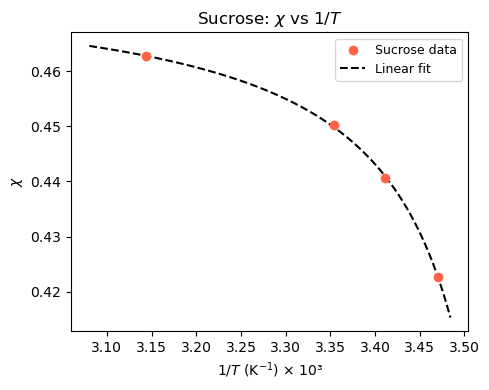

In [19]:
# Step 3 — plot chi vs 1/T
inv_T_fine_s = np.linspace(1/T_s.max()*0.98, 1/T_s.min()*1.004, 200)
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(1/T_s * 1e3, chi_s, color='tomato', zorder=5, label='Sucrose data')
ax.plot(inv_T_fine_s * 1e3, pade_chi(inv_T_fine_s, b0, b1, b2), 'k--', label='Linear fit')

ax.set_xlabel(r'$1/T$ (K$^{-1}$) × 10³')
ax.set_ylabel(r'$\chi$')
ax.set_title(r'Sucrose: $\chi$ vs $1/T$')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


---
## Summary

In this exercise you derived the three Flory–Huggins cosolute parameters from first principles:

| Parameter | Source data | Method |
|-----------|-------------|--------|
| $\nu$ | Density vs molality | Fit molar volume vs mole fraction |
| $\chi$ | Water activity at 25 °C | Fit FH $\ln(a_W)$ expression |
| $\chi_{TS}$ | Water activity for multiple temperatures | Linear regression /  Pad´e approximant of $\chi(T)$ vs $1/T$ |
